## LOAD DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load hasil output notebook 06
df = pd.read_csv("/content/final_brand_comparison_tanpa_kuadran.csv")

print("Shape:", df.shape)
print("Kolom:", df.columns.tolist())

Shape: (14, 14)
Kolom: ['Brand', 'Sentiment_Score_Avg', 'Weighted_Sentiment', 'Positif_Pct', 'Negatif_Pct', 'Total', 'total_listing', 'total_terjual', 'avg_harga', 'norm_sentiment', 'norm_terjual', 'norm_harga', 'composite_score', 'rank_composite']


In [3]:
df.head()

,Brand,Sentiment_Score_Avg,Weighted_Sentiment,Positif_Pct,Negatif_Pct,Total,total_listing,total_terjual,avg_harga,norm_sentiment,norm_terjual,norm_harga,composite_score,rank_composite
0,Infinix,0.0699,0.4305,20.3,13.3,472,582,618540,1918193.52,0.874568,1.000000,0.147280,0.7366,1
1,Vivo,0.1226,0.6191,23.2,11.0,155,347,385559,2983920.42,1.000000,0.623306,0.253229,0.6815,2
2,Samsung,0.0647,0.3905,18.7,12.2,417,818,428385,4412702.02,0.847965,0.692549,0.395271,0.6804,3
3,Sony,0.2222,0.5116,22.2,0.0,9,5,52,10495600.00,0.928505,0.000000,1.000000,0.6214,4
4,Apple,0.0845,0.4194,28.2,19.7,142,154,97177,8205674.99,0.867185,0.157036,0.772348,0.5949,5


**Interpretasi:** output notebook sebelumnya (notebook 06_correlation_analyst). File ini berisi data tiap brand smartphone beserta skor sentiment, data penjualan, harga, dan composite score tetapi belum ada memiliki kolom kuadran.

## MENENTUKAN THRESHOLD KUADRAN

In [4]:
# Threshold menggunakan median
threshold_sentiment = df['Weighted_Sentiment'].median()
threshold_terjual = df['total_terjual'].median()

print("Threshold Weighted Sentiment (median):", round(threshold_sentiment, 4))
print("Threshold Total Terjual (median)     :", int(threshold_terjual))

Threshold Weighted Sentiment (median): 0.1377
Threshold Total Terjual (median)     : 49545


**Interpretasi:** Threshold ditentukan menggunakan nilai median pada dua variabel utama: Weighted_Sentiment (0.1377) dan total_terjual (49.545). Pemilihan median didasarkan pada karakteristik distribusi data penjualan yang tidak normal (right-skewed) akibat adanya outlier seperti Infinix (618.540 unit), sehingga median lebih representatif dibandingkan mean sebagai titik pemisah.

## KLASIFIKASI KUADRAN

In [5]:
# Fungsi klasifikasi kuadran
def klasifikasi_kuadran(sentiment, terjual, thr_sent, thr_terjual):
    if sentiment >= thr_sent and terjual >= thr_terjual:
        return 'Star Brand'
    elif sentiment >= thr_sent and terjual < thr_terjual:
        return 'Hidden Gem'
    elif sentiment < thr_sent and terjual >= thr_terjual:
        return 'Overrated'
    else:
        return 'Underperformer'

# Terapkan ke setiap brand
df['kuadran'] = df.apply(
    lambda row: klasifikasi_kuadran(
        row['Weighted_Sentiment'],
        row['total_terjual'],
        threshold_sentiment,
        threshold_terjual
    ),
    axis=1
)

print(df[['Brand', 'Weighted_Sentiment', 'total_terjual', 'kuadran']].to_string(index=False))

   Brand  Weighted_Sentiment  total_terjual        kuadran
 Infinix              0.4305         618540     Star Brand
    Vivo              0.6191         385559     Star Brand
 Samsung              0.3905         428385     Star Brand
    Sony              0.5116             52     Hidden Gem
   Apple              0.4194          97177     Star Brand
  Xiaomi              0.5990         144710     Star Brand
   Nokia              0.3584          56666     Star Brand
  Huawei             -0.1637            630 Underperformer
Motorola             -0.0830           1610 Underperformer
    Oppo             -0.2890          71376      Overrated
    Asus             -0.5104             73 Underperformer
    iQOO             -0.3783           2100 Underperformer
  Realme             -0.7111          42424 Underperformer
   Tecno             -0.8845          22778 Underperformer


**Interpretasi:** Setiap brand diklasifikasikan ke dalam salah satu dari empat kuadran berdasarkan kombinasi nilai sentiment dan penjualan relatif terhadap threshold. Dari 14 brand, mayoritas (7 brand) masuk ke kategori Star Brand, diikuti Underperformer (5 brand), serta masing-masing satu brand pada Hidden Gem (Sony) dan Overrated (Oppo). Distribusi ini menunjukkan bahwa pasar smartphone dalam dataset didominasi brand dengan persepsi positif sekaligus volume penjualan tinggi, namun terdapat kesenjangan nyata pada sebagian brand antara persepsi konsumen dan realisasi penjualan.

In [6]:
# Filter brand dengan komentar YouTube minimal 30
# (konsisten dengan keputusan di notebook sentiment analysis Putri)
df_filtered = df[df['Total'] >= 30].copy()

print(f"Brand sebelum filter: {len(df)}")
print(f"Brand setelah filter (min 30 komentar): {len(df_filtered)}")
print(f"\nBrand yang dikeluarkan:")
print(df[df['Total'] < 30][['Brand', 'Total', 'kuadran']].to_string(index=False))

Brand sebelum filter: 14
Brand setelah filter (min 30 komentar): 11

Brand yang dikeluarkan:
 Brand  Total        kuadran
  Sony      9     Hidden Gem
 Nokia      5     Star Brand
Huawei     18 Underperformer


**Interpretasi:** Tiga brand dikeluarkan dari analisis kuadran karena jumlah komentar YouTube di bawah ambang batas reliabilitas (< 30 komentar):

* Sony (9 komentar),
* Nokia (5 komentar),
* Huawei (18 komentar).

Filter ini digunakan untuk menghitung skor sentimen dari sampel yang terlalu kecil namun memiliki varians yang tinggi dan tidak dapat dianggap representatif terhadap persepsi konsumen secara umum. Dataset analitik akhir menjadi 11 brand.

In [7]:
# Hitung ulang threshold dari data yang sudah difilter
threshold_sentiment = df_filtered['Weighted_Sentiment'].median()
threshold_terjual = df_filtered['total_terjual'].median()

print("Threshold baru setelah filter:")
print("Median Weighted Sentiment:", round(threshold_sentiment, 4))
print("Median Total Terjual     :", int(threshold_terjual))

# Klasifikasi ulang kuadran
df_filtered['kuadran'] = df_filtered.apply(
    lambda row: klasifikasi_kuadran(
        row['Weighted_Sentiment'],
        row['total_terjual'],
        threshold_sentiment,
        threshold_terjual
    ),
    axis=1
)

print("\n")
print(df_filtered[['Brand', 'Weighted_Sentiment', 'total_terjual', 'kuadran']].to_string(index=False))

Threshold baru setelah filter:
Median Weighted Sentiment: -0.083
Median Total Terjual     : 71376


   Brand  Weighted_Sentiment  total_terjual        kuadran
 Infinix              0.4305         618540     Star Brand
    Vivo              0.6191         385559     Star Brand
 Samsung              0.3905         428385     Star Brand
   Apple              0.4194          97177     Star Brand
  Xiaomi              0.5990         144710     Star Brand
Motorola             -0.0830           1610     Hidden Gem
    Oppo             -0.2890          71376      Overrated
    Asus             -0.5104             73 Underperformer
    iQOO             -0.3783           2100 Underperformer
  Realme             -0.7111          42424 Underperformer
   Tecno             -0.8845          22778 Underperformer


**Interpretasi:** Setelah filter diterapkan, threshold dihitung ulang dari distribusi 11 brand yang tersisa. Threshold sentiment turun signifikan dari +0.1377 menjadi -0.083, sedangkan threshold penjualan naik dari 49.545 menjadi 71.376. Pergeseran ini terjadi karena brand-brand dengan sentiment positif namun penjualan sangat rendah (Sony, Nokia) tidak lagi masuk perhitungan, menggeser titik tengah distribusi ke bawah. Dampaknya, Motorola yang sebelumnya Underperformer berpindah ke kuadran Hidden Gem karena sentimentnya (-0.083) kini tepat memenuhi threshold baru. Hasil klasifikasi final: Star Brand 5 brand, Hidden Gem 1 brand, Overrated 1 brand, Underperformer 4 brand.

## VIASUALISASI BUBBLE CHART KUADRAN

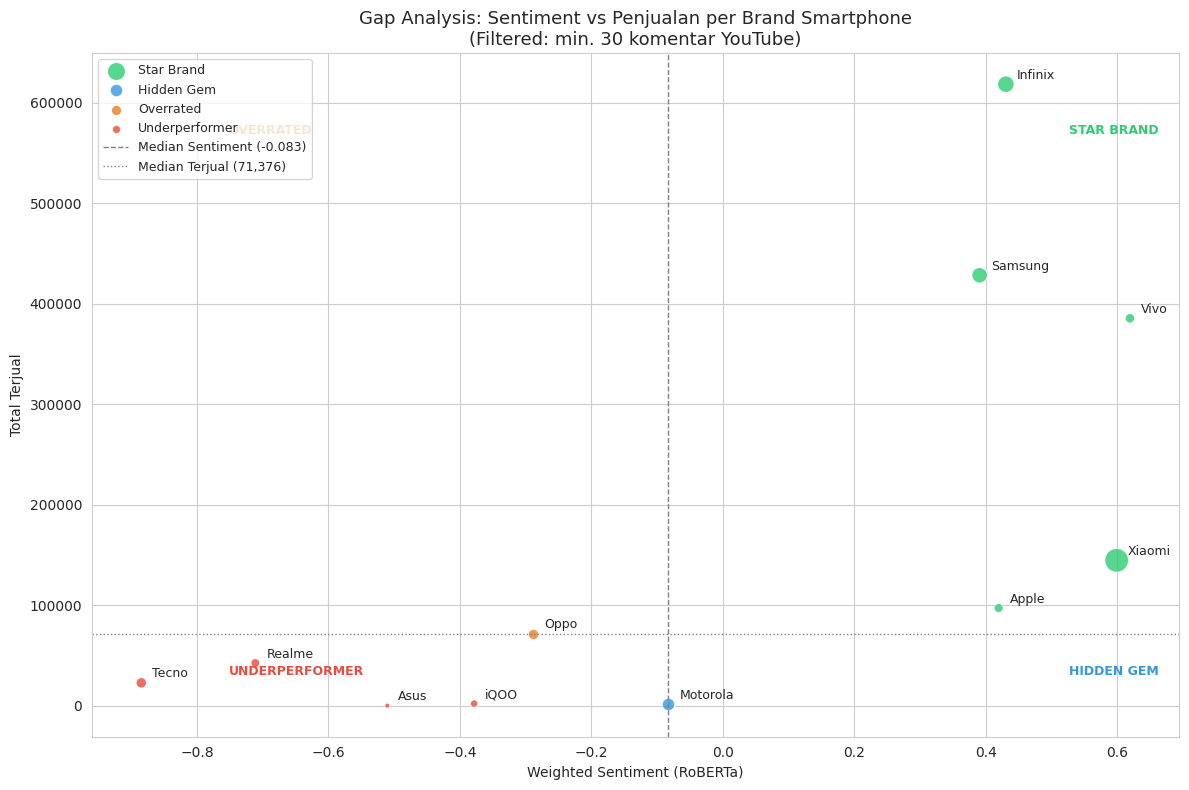

In [8]:
# Warna per kuadran
warna_kuadran = {
    'Star Brand'    : '#2ecc71',   # hijau
    'Hidden Gem'   : '#3498db',   # biru
    'Overrated'    : '#e67e22',   # oranye
    'Underperformer': '#e74c3c'    # merah
}

# Visualisasi ulang bubble chart dengan data filtered
plt.figure(figsize=(12, 8))

for kuadran, color in warna_kuadran.items():
    subset = df_filtered[df_filtered['kuadran'] == kuadran]
    plt.scatter(
        subset['Weighted_Sentiment'],
        subset['total_terjual'],
        c=color,
        s=subset['Total'] * 0.3,
        label=kuadran,
        alpha=0.8,
        edgecolors='white',
        linewidth=0.8
    )

for _, row in df_filtered.iterrows():
    plt.annotate(
        row['Brand'],
        (row['Weighted_Sentiment'], row['total_terjual']),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9
    )

plt.axvline(threshold_sentiment, color='gray', linestyle='--',
            linewidth=1, label=f'Median Sentiment ({threshold_sentiment:.3f})')
plt.axhline(threshold_terjual, color='gray', linestyle=':',
            linewidth=1, label=f'Median Terjual ({int(threshold_terjual):,})')

plt.text(df_filtered['Weighted_Sentiment'].max() * 0.85,
         df_filtered['total_terjual'].max() * 0.92,
         'STAR BRAND', fontsize=9, color='#2ecc71', fontweight='bold')
plt.text(df_filtered['Weighted_Sentiment'].max() * 0.85,
         df_filtered['total_terjual'].max() * 0.05,
         'HIDDEN GEM', fontsize=9, color='#3498db', fontweight='bold')
plt.text(df_filtered['Weighted_Sentiment'].min() * 0.85,
         df_filtered['total_terjual'].max() * 0.92,
         'OVERRATED', fontsize=9, color='#e67e22', fontweight='bold')
plt.text(df_filtered['Weighted_Sentiment'].min() * 0.85,
         df_filtered['total_terjual'].max() * 0.05,
         'UNDERPERFORMER', fontsize=9, color='#e74c3c', fontweight='bold')

plt.title("Gap Analysis: Sentiment vs Penjualan per Brand Smartphone\n(Filtered: min. 30 komentar YouTube)", fontsize=13)
plt.xlabel("Weighted Sentiment (RoBERTa)")
plt.ylabel("Total Terjual")
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

**Interpretasi:** Bubble chart memvisualisasikan tiga dimensi secara simultan, yaitu sentiment (sumbu X), penjualan (sumbu Y), dan jumlah komentar YouTube sebagai ukuran bubble. Garis putus-putus vertikal dan horizontal merepresentasikan nilai median masing-masing dimensi sebagai pemisah kuadran.

Secara visual terlihat bahwa Star Brand terkonsentrasi di kuadran kanan atas dengan bubble besar, mengindikasikan korelasi positif antara volume engagement YouTube, persepsi konsumen, dan performa penjualan. Sebaliknya, Underperformer tersebar di kuadran kiri bawah dengan bubble kecil, mencerminkan rendahnya engagement sekaligus penjualan yang lemah.

In [9]:
# Print hasil klasifikasi final
print("HASIL GAP ANALYSIS FINAL (min. 30 komentar)")

urutan = ['Star Brand', 'Hidden Gem', 'Overrated', 'Underperformer']

for k in urutan:
    brands = df_filtered[df_filtered['kuadran'] == k]['Brand'].tolist()
    print(f"\n{k} ({len(brands)} brand):")
    for b in brands:
        row = df_filtered[df_filtered['Brand'] == b].iloc[0]
        print(f"   {b:12} | Sentiment: {row['Weighted_Sentiment']:+.4f} | Terjual: {int(row['total_terjual']):>7,}")

HASIL GAP ANALYSIS FINAL (min. 30 komentar)

Star Brand (5 brand):
   Infinix      | Sentiment: +0.4305 | Terjual: 618,540
   Vivo         | Sentiment: +0.6191 | Terjual: 385,559
   Samsung      | Sentiment: +0.3905 | Terjual: 428,385
   Apple        | Sentiment: +0.4194 | Terjual:  97,177
   Xiaomi       | Sentiment: +0.5990 | Terjual: 144,710

Hidden Gem (1 brand):
   Motorola     | Sentiment: -0.0830 | Terjual:   1,610

Overrated (1 brand):
   Oppo         | Sentiment: -0.2890 | Terjual:  71,376

Underperformer (4 brand):
   Asus         | Sentiment: -0.5104 | Terjual:      73
   iQOO         | Sentiment: -0.3783 | Terjual:   2,100
   Realme       | Sentiment: -0.7111 | Terjual:  42,424
   Tecno        | Sentiment: -0.8845 | Terjual:  22,778


## STATISTIK PER KUADRAN

In [10]:
# Statistik per kuadran
ringkasan = df_filtered.groupby('kuadran').agg(
    jumlah_brand  = ('Brand', 'count'),
    avg_sentiment = ('Weighted_Sentiment', 'mean'),
    avg_terjual   = ('total_terjual', 'mean'),
    avg_harga     = ('avg_harga', 'mean'),
    avg_composite = ('composite_score', 'mean')
).round(4).reset_index()

print("\nStatistik per Kuadran:")
ringkasan


Statistik per Kuadran:


,kuadran,jumlah_brand,avg_sentiment,avg_terjual,avg_harga,avg_composite
0,Hidden Gem,1,-0.0830,1610.00,3.616361e+06,0.2931
1,Overrated,1,-0.2890,71376.00,3.487174e+06,0.2746
2,Star Brand,5,0.4917,334874.20,4.131398e+06,0.6474
3,Underperformer,4,-0.6211,16843.75,3.931712e+06,0.1664


**Interpretasi:** Statistik agregat per kuadran mengonfirmasi pola yang tampak pada visualisasi. Star Brand mencatat rata-rata sentiment tertinggi (+0.49), rata-rata penjualan tertinggi (334.874 unit), sekaligus rata-rata harga tertinggi (Rp 4,13 juta) dan composite score tertinggi (0.647)

Hal ini menunjukkan bahwa persepsi positif konsumen sejalan dengan kesediaan membayar harga premium. Underperformer memiliki rata-rata sentiment paling negatif (-0.62) dan composite score terendah (0.166), meski rata-rata harganya (Rp 3,93 juta) lebih tinggi dari Overrated dan Hidden Gem, mengindikasikan adanya value-for-money gap yang dirasakan konsumen. Overrated (Oppo) menunjukkan kondisi anomali di mana penjualan berada tepat di median namun sentiment negatif (-0.29), yang dapat mengindikasikan risiko erosi loyalitas konsumen dalam jangka menengah.

In [11]:
rekomendasi = {
    'Star Brand': {
        'icon': '⭐',
        'label': 'PERTAHANKAN & KEMBANGKAN',
        'strategi': [
            'Pertahankan kualitas produk dan layanan purna jual',
            'Perluas ke segmen harga baru (naik ke premium atau turun ke budget)',
            'Manfaatkan sentimen positif untuk kampanye word-of-mouth',
            'Fokus pada loyalitas pelanggan — program reward/trade-in',
        ]
    },
    'Hidden Gem': {
        'icon': '💎',
        'label': 'TINGKATKAN VISIBILITAS',
        'strategi': [
            'Sentimen positif sudah ada — masalah utama adalah awareness',
            'Tingkatkan anggaran iklan di marketplace (flash sale, top ads)',
            'Kolaborasi dengan YouTuber/reviewer untuk memperluas jangkauan',
            'Optimalkan listing produk: foto, deskripsi, dan harga kompetitif',
        ]
    },
    'Overrated': {
        'icon': '⚠️',
        'label': 'PERBAIKI KUALITAS PRODUK',
        'strategi': [
            'Penjualan tinggi tapi sentimen buruk = risiko churn tinggi',
            'Investigasi keluhan utama konsumen (kamera, baterai, software)',
            'Prioritaskan perbaikan pada model yang paling banyak dikeluhkan',
            'Tingkatkan layanan after-sales dan response time customer service',
        ]
    },
    'Underperformer': {
        'icon': '🔴',
        'label': 'EVALUASI MENYELURUH',
        'strategi': [
            'Evaluasi positioning produk: apakah sesuai kebutuhan pasar Indonesia?',
            'Pertimbangkan price cut atau bundling untuk meningkatkan penjualan',
            'Review kualitas produk sekaligus strategi marketing',
            'Benchmark kompetitor di segmen yang sama',
        ]
    }
}

print("=" * 65)
print("REKOMENDASI STRATEGIS BERDASARKAN GAP ANALYSIS")
print("=" * 65)

for kuadran in ['Star Brand', 'Hidden Gem', 'Overrated', 'Underperformer']:
    brands_in = df_filtered[df_filtered['kuadran'] == kuadran]['Brand'].tolist()
    if not brands_in:
        continue
    rek = rekomendasi[kuadran]
    print(f"\n{rek['icon']} {kuadran} — {rek['label']}")
    print(f"   Brand: {', '.join(brands_in)}")
    print(f"   Strategi:")
    for s in rek['strategi']:
        print(f"   → {s}")

print("\n" + "=" * 65)
print("RINGKASAN EKSEKUTIF")
print("=" * 65)
total = len(df_filtered)
for k in ['Star Brand', 'Hidden Gem', 'Overrated', 'Underperformer']:
    n = len(df_filtered[df_filtered['kuadran']==k])
    brands = df_filtered[df_filtered['kuadran']==k]['Brand'].tolist()
    print(f"  {k:<15}: {n} brand ({n/total*100:.0f}%) — {', '.join(brands) if brands else '-'}")

REKOMENDASI STRATEGIS BERDASARKAN GAP ANALYSIS

⭐ Star Brand — PERTAHANKAN & KEMBANGKAN
   Brand: Infinix, Vivo, Samsung, Apple, Xiaomi
   Strategi:
   → Pertahankan kualitas produk dan layanan purna jual
   → Perluas ke segmen harga baru (naik ke premium atau turun ke budget)
   → Manfaatkan sentimen positif untuk kampanye word-of-mouth
   → Fokus pada loyalitas pelanggan — program reward/trade-in

💎 Hidden Gem — TINGKATKAN VISIBILITAS
   Brand: Motorola
   Strategi:
   → Sentimen positif sudah ada — masalah utama adalah awareness
   → Tingkatkan anggaran iklan di marketplace (flash sale, top ads)
   → Kolaborasi dengan YouTuber/reviewer untuk memperluas jangkauan
   → Optimalkan listing produk: foto, deskripsi, dan harga kompetitif

⚠️ Overrated — PERBAIKI KUALITAS PRODUK
   Brand: Oppo
   Strategi:
   → Penjualan tinggi tapi sentimen buruk = risiko churn tinggi
   → Investigasi keluhan utama konsumen (kamera, baterai, software)
   → Prioritaskan perbaikan pada model yang paling bany

## PENYIMPANAN OUTPUT

In [12]:
# Simpan final_brand_comparison dengan kolom kuadran
df.to_csv("final_brand_comparison_dengan_kuadran.csv", index=False)

# Simpan juga versi ranking
df_ranked = df.sort_values('composite_score', ascending=False).reset_index(drop=True)
df_ranked['final_rank'] = df_ranked.index + 1
df_ranked.to_csv("final_ranked.csv", index=False)

print("Tersimpan: final_brand_comparison.csv (dengan kolom kuadran)")
print("Tersimpan: final_ranked.csv (ranking final)")
print("\nPreview final_ranked.csv:")
print(df_ranked[['final_rank', 'Brand', 'composite_score', 'kuadran']].to_string(index=False))

Tersimpan: final_brand_comparison.csv (dengan kolom kuadran)
Tersimpan: final_ranked.csv (ranking final)

Preview final_ranked.csv:
 final_rank    Brand  composite_score        kuadran
          1  Infinix           0.7366     Star Brand
          2     Vivo           0.6815     Star Brand
          3  Samsung           0.6804     Star Brand
          4     Sony           0.6214     Hidden Gem
          5    Apple           0.5949     Star Brand
          6   Xiaomi           0.5436     Star Brand
          7    Nokia           0.3627     Star Brand
          8   Huawei           0.3526 Underperformer
          9 Motorola           0.2931 Underperformer
         10     Oppo           0.2746      Overrated
         11     Asus           0.2513 Underperformer
         12     iQOO           0.2287 Underperformer
         13   Realme           0.1220 Underperformer
         14    Tecno           0.0637 Underperformer
